In [ ]:
"""
Visualización del ejemplo "una función, tres series distintas":
f(z) = 1 / ((z - 1)(z - 2)) y sus tres series de Laurent,
una por anillo de convergencia: |z| < 1, 1 < |z| < 2, |z| > 2.
"""

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

In [ ]:
plt.rcParams.update({
    'font.size': 14,
    'text.usetex': False
})

In [ ]:
# --- Dominio del plano complejo ---
x = np.linspace(-3, 3, 600)
y = np.linspace(-3, 3, 600)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

In [ ]:
# --- Función exacta ---
with np.errstate(divide="ignore", invalid="ignore"):
    F = 1.0 / ((Z - 1) * (Z - 2))

In [ ]:
mod_F = np.abs(F)
fase_F = np.angle(F)

In [1]:
# --- Series de Laurent truncadas (N términos por serie) ---
N = 20

In [2]:
def serie_disco(z, N=N):
    """Región |z| < 1: f = sum (1 - 2^{-(n+1)}) z^n  (serie de Taylor)."""
    n = np.arange(N + 1)
    a_n = 1.0 - 2.0 ** (-(n + 1))
    return sum(a_n[k] * z**k for k in range(N + 1))

In [3]:
def serie_anillo(z, N=N):
    """Región 1 < |z| < 2: f = -sum z^{-n} - sum z^n / 2^{n+1}."""
    s = np.zeros_like(z)
    for k in range(1, N + 1):
        s = s - z ** (-k)
    for k in range(0, N + 1):
        s = s - z**k / 2.0 ** (k + 1)
    return s

In [4]:
def serie_exterior(z, N=N):
    """Región |z| > 2: f = sum (2^{n-1} - 1) z^{-n}."""
    s = np.zeros_like(z)
    for k in range(1, N + 1):
        s = s + (2.0 ** (k - 1) - 1.0) * z ** (-k)
    return s

In [5]:
with np.errstate(divide="ignore", invalid="ignore"):
    S1 = serie_disco(Z)
    S2 = serie_anillo(Z)
    S3 = serie_exterior(Z)

In [6]:
# Error |S_N - f| en escala logarítmica
err1 = np.log10(np.abs(S1 - F) + 1e-16)
err2 = np.log10(np.abs(S2 - F) + 1e-16)
err3 = np.log10(np.abs(S3 - F) + 1e-16)

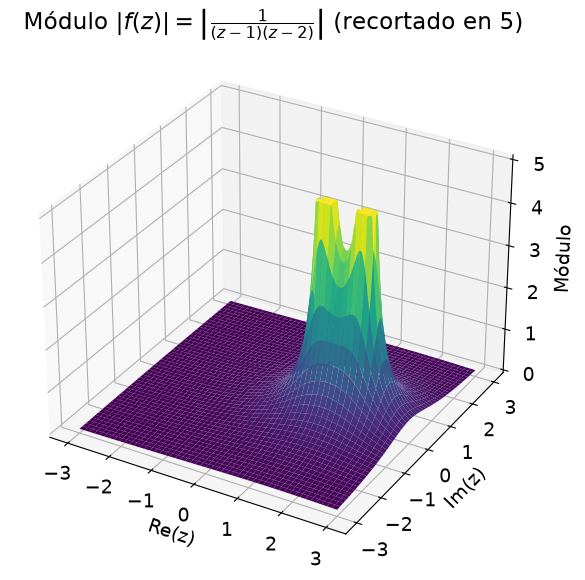

In [7]:
# --- Figura 1a: módulo 3D ---
fig_mod = plt.figure(figsize=(7, 6))
ax1 = fig_mod.add_subplot(1, 1, 1, projection="3d")
ax1.plot_surface(X, Y, np.clip(mod_F, 0, 5), cmap="viridis", edgecolor="none")
ax1.set_title(r"Módulo $|f(z)| = \left|\frac{1}{(z-1)(z-2)}\right|$ (recortado en 5)")
ax1.set_xlabel("Re(z)")
ax1.set_ylabel("Im(z)")
ax1.set_zlabel("Módulo")
plt.tight_layout()
#fig_mod.savefig('modulo_funcion.png', format='png') # Guardar como png
#plt.close(fig_mod) 
plt.show()

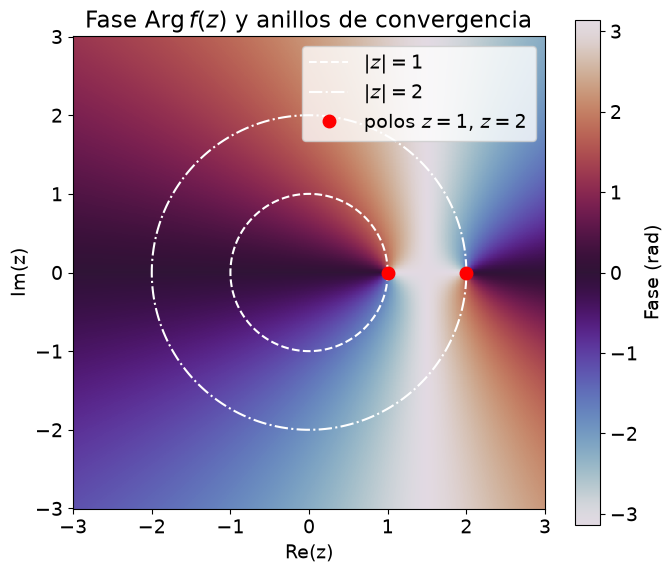

In [8]:
# --- Figura 1b: fase con los anillos ---
fig_fase = plt.figure(figsize=(7, 6))
ax2 = fig_fase.add_subplot(1, 1, 1)
im = ax2.pcolormesh(X, Y, fase_F, cmap="twilight", shading="auto", vmin=-np.pi, vmax=np.pi)
theta = np.linspace(0, 2 * np.pi, 400)
ax2.plot(np.cos(theta), np.sin(theta), "w--", lw=1.5, label=r"$|z|=1$")
ax2.plot(2 * np.cos(theta), 2 * np.sin(theta), "w-.", lw=1.5, label=r"$|z|=2$")
ax2.plot([1, 2], [0, 0], "ro", ms=9, label="polos $z=1$, $z=2$")
ax2.set_title(r"Fase $\mathrm{Arg}\, f(z)$ y anillos de convergencia")
ax2.set_xlabel("Re(z)")
ax2.set_ylabel("Im(z)")
ax2.set_aspect("equal")
ax2.legend(loc="upper right")
fig_fase.colorbar(im, ax=ax2, label="Fase (rad)")
plt.tight_layout()
#fig_fase.savefig('fase_anillos.png', format='png') # Guardar como png
#plt.close(fig_fase)
plt.show()

In [ ]:
# --- Figura 2: error de cada serie truncada en TODO el plano ---
fig2, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, layout="constrained")
errores = [
    (err1, r"$\sum_{n\geq 0}\left(1-\frac{1}{2^{n+1}}\right)z^n$", r"$|z|<1$"),
    (err2, r"$-\sum_{n\geq 1} z^{-n} - \sum_{n\geq 0}\frac{z^n}{2^{n+1}}$", r"$1<|z|<2$"),
    (err3, r"$\sum_{n\geq 1}\left(2^{n-1}-1\right) z^{-n}$", r"$|z|>2$"),
]

In [ ]:
for ax, (err, serie_txt, region_txt) in zip(axes, errores):
    pc = ax.pcolormesh(X, Y, err, cmap="magma", shading="auto", vmin=-16, vmax=2)
    ax.plot(np.cos(theta), np.sin(theta), "c--", lw=1.5)
    ax.plot(2 * np.cos(theta), 2 * np.sin(theta), "c-.", lw=1.5)
    ax.plot([1, 2], [0, 0], "wo", ms=8, mec="k")
    ax.set_title(f"Región {region_txt}\n$S_{{{N}}}(z) = {serie_txt[1:]}")
    ax.set_xlabel("Re(z)")
    ax.set_aspect("equal")

In [ ]:
axes[0].set_ylabel("Im(z)")
fig2.suptitle(
    r"$\log_{10}|S_N(z) - f(z)|$ con $N = %d$: cada serie solo converge en su anillo "
    "(azul oscuro = coincide con $f$)" % N,
    fontsize=12,
)
fig2.colorbar(pc, ax=axes, label=r"$\log_{10}$ error", shrink=0.9)

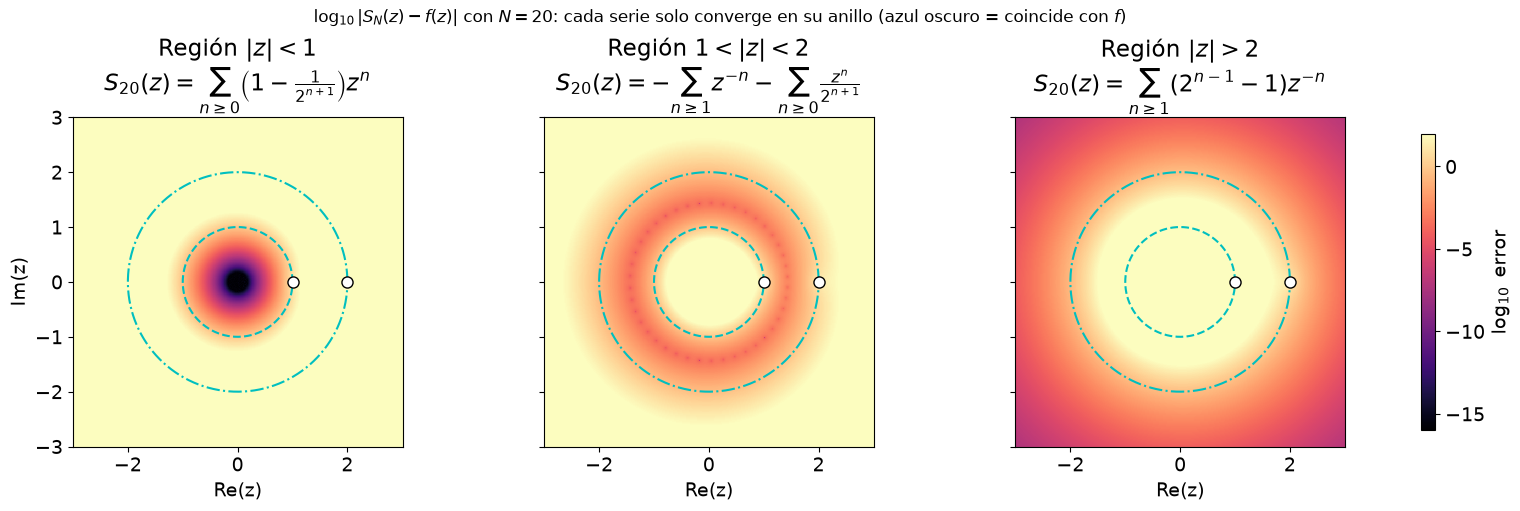

In [9]:
#fig2.savefig('errores_series_laurent.png', format='png') # Guardar como png
#plt.close(fig2)
plt.show()